In [1]:
import sys
MODULEPATH="../../"
sys.path.append(MODULEPATH)
sys.path.append('../')

import pandas as pd
import matplotlib.pyplot as plt

from test_schwefel.schwefel_function import schwefel4D, schwefel4D_numpy
from connectivity.connectivity import trace_connectivity, extract_connection_indices, save_descent_paths
from connectivity.saddle_tree_calculations import saddle_tree_calculations
from connectivity.plot_results import plot_saddle_tree_with_function

In [2]:
critical_points_file = "./critical_points_schwefel_4D.csv"

dataframe = pd.read_csv(critical_points_file)
saddles_df = dataframe[dataframe["type"] == "saddle"]
minima_df = dataframe[dataframe["type"] == "minimum"]
func = lambda x: schwefel4D(x[0], x[1], x[2], x[3])

In [3]:
all_results, minima, dataframe, paths = trace_connectivity(
    saddles_df, minima_df, dataframe ,func, return_paths=True
)

In [4]:
save_descent_paths(paths)
extract_connection_indices(all_results, dataframe)
saddle_tree_calculations(all_results, minima, dataframe)

Saved 513 connections to results/saddle_to_minima_indices4D.csv
Saved node order to results/tree_nodes.csv
Saved tree edges to results/tree_connectivity.csv


/tmp/ipykernel_378943/1099895721.py:13: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig1.show()


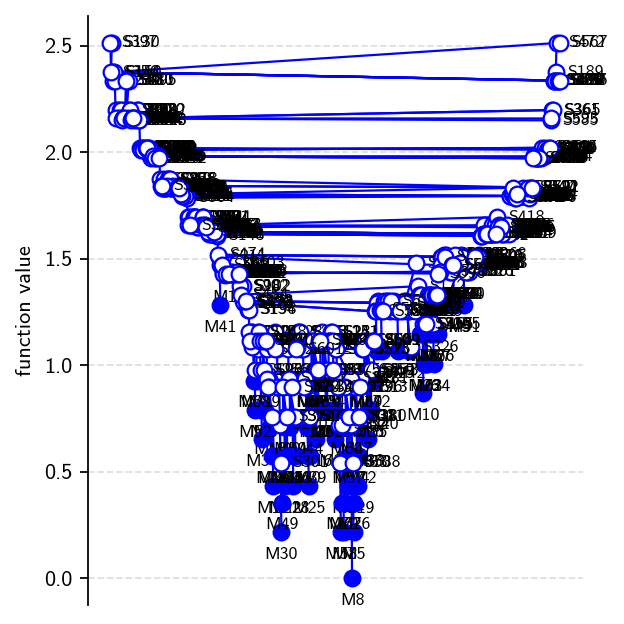

In [5]:
fig1 = plt.figure(figsize=(4,4), dpi=160)

fig1 = plot_saddle_tree_with_function(dataframe, 
                                        nodes_csv="results/tree_nodes.csv",
                                        edges_csv="results/tree_connectivity.csv", 
                                        fig=fig1)

ax = fig1.axes[0]
ax.set_ylabel("function value")
# ax.yaxis.set_major_locator(MaxNLocator(10))
fig1.tight_layout()

fig1.show()
fig1.savefig("plots/tree_plot.png")  # Optional